In [17]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize,sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [19]:
df=pd.read_csv("/content/nlp_dataset.csv")

In [20]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [21]:
stopwords = set(stopwords.words('english'))
print(stopwords)
Lemmatizer =WordNetLemmatizer()


{'isn', 'on', "she's", 'just', 'more', 'o', 'did', "they're", 'too', 'me', 'can', 'nor', 'are', 'do', 'before', "aren't", "should've", 'same', 'was', 'from', 'such', 'd', 'shan', 'yourselves', 'against', 'doing', 'up', 'mightn', 'theirs', 'when', 'but', "we've", 'and', 'below', 'them', 'having', 'his', 'we', 'out', 'this', "we're", 'ourselves', "shan't", 'than', 's', 'while', 'down', 'very', 'won', "we'll", 'not', 'mustn', 'a', 'being', "wouldn't", "you've", 'themselves', 'had', 'hers', "it's", "shouldn't", 'should', 'under', "couldn't", 'or', 'who', 'where', 'y', 'as', 'ma', 'him', 'to', 'whom', 'about', 'i', 'weren', "they've", "they'd", 'any', "hasn't", 'you', "weren't", "didn't", 'her', 'once', 'some', 'have', "hadn't", "doesn't", 'couldn', 'am', 'the', 'each', 'both', "we'd", 'he', 'yours', 'because', 'between', "haven't", 'only', "needn't", "i'm", 'now', 'for', "that'll", "she'll", 'then', 'itself', 'their', "they'll", 'here', 'ain', 'wasn', 'into', 'will', 'after', 'how', 'mysel

In [22]:
def process_text(text):
  word_tokens = word_tokenize(text)

  filtered_tokens = [word for word in word_tokens if word.lower() not in stopwords]
  lemmatized_tokens = [Lemmatizer.lemmatize(word.lower()) for word in filtered_tokens]

  return{
      "Original Text":text,
      "Word Tokens":word_tokens,
      "Filtered Tokens":filtered_tokens,
      "Lemmatized Tokens":lemmatized_tokens
  }

In [23]:
df

,Text
0,Natural Language Processing is a fascinating f...
1,It bridges the gap between humans and machines...
2,NLP techniques are widely used in applications...
3,Machine translation and speech recognition are...
4,"Despite its advancements, NLP faces challenges..."
5,Continuous research and innovation are improvi...
6,"The potential of NLP is vast, making it essent..."


In [24]:
results =df['Text'].apply(process_text)

In [25]:
processed_df=pd.DataFrame(results.tolist())
print(processed_df.head())

                                       Original Text  ...                                  Lemmatized Tokens
0  Natural Language Processing is a fascinating f...  ...  [natural, language, processing, fascinating, f...
1  It bridges the gap between humans and machines...  ...  [bridge, gap, human, machine, enabling, comput...
2  NLP techniques are widely used in applications...  ...  [nlp, technique, widely, used, application, ch...
3  Machine translation and speech recognition are...  ...  [machine, translation, speech, recognition, co...
4  Despite its advancements, NLP faces challenges...  ...  [despite, advancement, ,, nlp, face, challenge...

[5 rows x 4 columns]


In [26]:
processed_file_path ="processed_nip_dataset.csv"
processed_df.to_csv(processed_file_path,index=False)
print(f'processed dataset saved to {processed_file_path}')



processed dataset saved to processed_nip_dataset.csv


In [27]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

In [28]:
text_data =[
    "Natural Language Processing is a fascinating field of Artificial Intelligence.",
    "It bridges the gap between humans and machines by enabling computers to understand human language.",
    "NLP techniques are widely used in applications such as chatbots and sentiment analysis.",
    "Machine translation and speech recognition are common use cases of NLP.",
    "Despite its advancements, NLP faces challenges including ambiguity in language.",
    "Continuous research and innovation are improving NLP rapidly.",
    "The potential of NLP is vast, making it essential in modern technology."
]

In [29]:
vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(text_data)
bow_df= pd.DataFrame(bow_matrix.toarray(), columns=vectorizer.get_feature_names_out())
print("Bag of Words Representation:")
print(bow_df)
bow_df.to_csv("bag_of_words.csv",index=False)
print("\nBag of Words saved as 'bag_of_words.csv'.")


Bag of Words Representation:
   advancements  ambiguity  analysis  and  ...  use  used  vast  widely
0             0          0         0    0  ...    0     0     0       0
1             0          0         0    1  ...    0     0     0       0
2             0          0         1    1  ...    0     1     0       1
3             0          0         0    1  ...    1     0     0       0
4             1          1         0    0  ...    0     0     0       0
5             0          0         0    1  ...    0     0     0       0
6             0          0         0    0  ...    0     0     1       0

[7 rows x 60 columns]

Bag of Words saved as 'bag_of_words.csv'.


In [31]:
bow_df

,advancements,ambiguity,analysis,and,applications,are,artificial,as,between,bridges,by,cases,challenges,chatbots,common,computers,continuous,despite,enabling,essential,faces,fascinating,field,gap,human,humans,improving,in,including,innovation,intelligence,is,it,its,language,machine,machines,making,modern,natural,nlp,of,potential,processing,rapidly,recognition,research,sentiment,speech,such,techniques,technology,the,to,translation,understand,use,used,vast,widely
0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,1,0,0,0,0,1,1,1,0,0,0,0,1,0,0,1,0,0,0,0,1,1,1,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0
2,0,0,1,1,1,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,1
3,0,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0
4,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,1,1,0,1,1,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0


In [32]:
import pandas as pd
import nltk
from nltk.stem import WordNetLemmatizer,PorterStemmer
from nltk.tokenize import word_tokenize

In [35]:
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [36]:
file_path = "/content/nlp_dataset.csv"
data = pd.read_csv(file_path)

In [41]:
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

In [40]:
def lemmatize_text(Text):
  tokens = word_tokenize(str(Text))
  return ' '.join([lemmatizer.lemmatize(word) for word in tokens])
def stem_text(Text):
  tokens=word_tokenize(str(Text))
  return ' '.join([stemmer.stem(word) for word in tokens])

In [46]:
data['lemmatized_text'] = data['Text'].apply(lemmatize_text)
data['stemmed_text'] = data['Text'].apply(stem_text)
output_path ="lemmatization_vs_stemming.csv"
data.to_csv(output_path,index=False)
print(data[['Text', 'lemmatized_text', 'stemmed_text']])

print(f"Comparison dataset saved to {output_path}")

                                                Text  ...                                       stemmed_text
0  Natural Language Processing is a fascinating f...  ...  natur languag process is a fascin field of art...
1  It bridges the gap between humans and machines...  ...  it bridg the gap between human and machin by e...
2  NLP techniques are widely used in applications...  ...  nlp techniqu are wide use in applic such as ch...
3  Machine translation and speech recognition are...  ...  machin translat and speech recognit are common...
4  Despite its advancements, NLP faces challenges...  ...  despit it advanc , nlp face challeng includ am...
5  Continuous research and innovation are improvi...  ...  continu research and innov are improv nlp rapi...
6  The potential of NLP is vast, making it essent...  ...  the potenti of nlp is vast , make it essenti i...

[7 rows x 3 columns]
Comparison dataset saved to lemmatization_vs_stemming.csv


In [47]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

In [53]:
file_path = "/content/nlp_dataset.csv"
data=pd.read_csv(file_path)

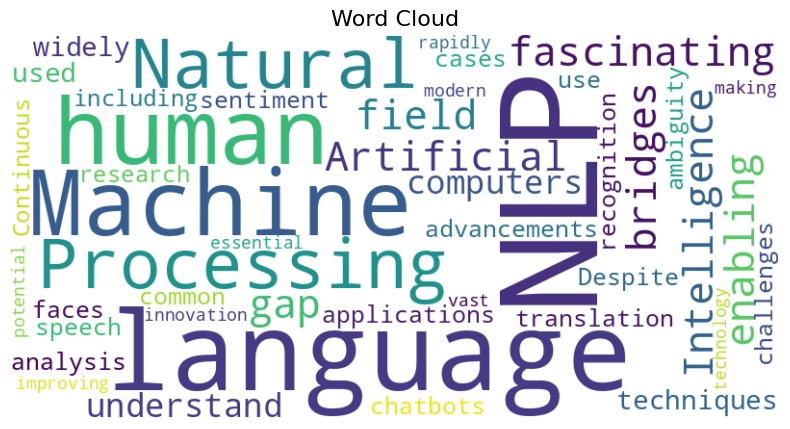

In [55]:
text_data= " ".join(data['Text'].dropna())
wordcloud = WordCloud(width=800,height=400,background_color='white').generate(text_data)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud",fontsize=16)
plt.show()